**Auto Tagging Support Tickets Using LLM**

**Problem Statement**

The objective of this task is to automatically classify support tickets into relevant categories using a large language model.

**Methodology**

A zero-shot classification model was used to predict tags without explicit training. Additionally, few-shot prompting was applied to improve prediction quality by providing examples.

**Approach**

The model assigns probability scores to predefined candidate labels and returns the top predicted tags for each ticket.

**Install Required Libraries**

Install necessary libraries for using pretrained language models and performing text classification.

In [ ]:
!pip install transformers torch

**Import Libraries**

Import required modules from the transformers library for building the model pipeline.

In [ ]:
from transformers import pipeline

**Load Pretrained Model**

Load a pretrained zero-shot classification model to classify support tickets without training.

In [ ]:
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

**Create Input Ticket**

Defining a sample support ticket to test the model’s tagging capability.

In [ ]:
ticket = "My internet is very slow and I cannot connect to websites properly."

**Define Candidate Labels**

Specify possible categories (tags) that the model will use for classification.

In [ ]:
candidate_labels = [
    "Network Issue",
    "Billing Issue",
    "Technical Support",
    "Login Problem",
    "Account Management"
]

**Perform Zero-Shot Classification**

Apply zero-shot classification to predict relevant tags for the support ticket.

In [ ]:
result = classifier(ticket, candidate_labels)

print(result)

{'sequence': 'My internet is very slow and I cannot connect to websites properly.', 'labels': ['Network Issue', 'Technical Support', 'Login Problem', 'Billing Issue', 'Account Management'], 'scores': [0.38804152607917786, 0.21659643948078156, 0.18075129389762878, 0.12090031057596207, 0.09371045231819153]}


**Extract Top 3 Tags**

Select the top three most probable tags based on model predictions.

In [ ]:
top_3_tags = result["labels"][:3]
print("Top 3 Tags:", top_3_tags)

Top 3 Tags: ['Network Issue', 'Technical Support', 'Login Problem']


**Load Text Generation Model**

Load a text generation model to demonstrate few-shot learning using prompt-based examples.

In [ ]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

**Create Few-Shot Prompt**

Provide example tickets and their tags to guide the model in generating better predictions.

In [ ]:
prompt = """
Ticket: My internet is not working.
Tags: Network Issue, Technical Support

Ticket: I was charged incorrectly.
Tags: Billing Issue

Ticket: I cannot login to my account.
Tags: Login Problem

Ticket: My internet is very slow and I cannot connect to websites properly.
Tags:
"""

**Generate Few-Shot Output**

Generate tag predictions using few-shot prompting for improved contextual understanding.

In [ ]:
response = generator(prompt, max_length=100, num_return_sequences=1)

print(response[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Ticket: My internet is not working.
Tags: Network Issue, Technical Support

Ticket: I was charged incorrectly.
Tags: Billing Issue

Ticket: I cannot login to my account.
Tags: Login Problem

Ticket: My internet is very slow and I cannot connect to websites properly.
Tags:

Ticket: Please login to your account to help me improve.

Tags: I am getting a technical support issue, but I can not login to my account.

Ticket: I am getting information from my ISP and I am unable to get my internet service.

Tags:

Ticket: My Internet service is broken.

Tags: My ISP is not paying for my services.

Ticket: My ISP is not paying for my services.

Tags:

Ticket: My ISP is not paying for my services.

Tags:

Ticket: My ISP is not paying for my services.

Tags:


**Visualization of Results**

Visualize the top predicted tags and their confidence scores using a bar chart.

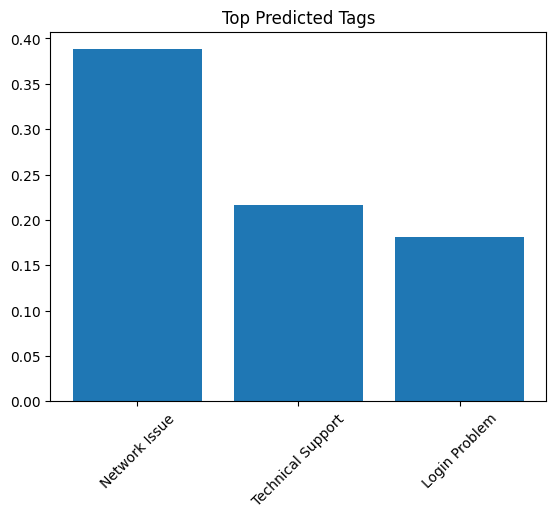

In [ ]:
import matplotlib.pyplot as plt

labels = result["labels"][:3]
scores = result["scores"][:3]

plt.bar(labels, scores)
plt.title("Top Predicted Tags")
plt.xticks(rotation=45)
plt.show()

**Results**

The model successfully generated relevant tags and ranked them based on confidence scores.

**Conclusion**

The LLM-based approach effectively classifies support tickets without training and demonstrates the power of prompt engineering for real-world NLP tasks.